In [ ]:
!jupyter nbconvert --execute --to html "/content/Lab2_EDA_Jena.ipynb"

[NbConvertApp] Converting notebook /content/Lab2_EDA_Jena.ipynb to html
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 485108 bytes to /content/Lab2_EDA_Jena.html


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io # Import io to handle string data as a file

# 1. Data Access
# Load the CSV file. It has tab-separated data inside a quoted field, followed by commas.
# We can read the first column using quotechar, then split it.
temp_csv = pd.read_csv('/content/Facebook Friends.csv', header=None, quotechar='"')
# Column 0 contains the tab separated data. Split it into new columns.
df_csv = temp_csv.iloc[:, 0].str.split('\t', expand=True)
# The first row of the split dataframe is the header
df_csv.columns = df_csv.iloc[0].str.strip()
df_csv = df_csv[1:].reset_index(drop=True)

# Load the TXT file with tab delimiter and utf-16 encoding
df_txt = pd.read_csv('/content/Facebook Friends.txt', encoding='utf-16', sep='\t')
# Drop columns that start with 'Unnamed:' which were created due to leading tabs in the raw file
df_txt = df_txt.loc[:, ~df_txt.columns.str.startswith('Unnamed:')]
# Clean up column names by stripping whitespace
df_txt.columns = df_txt.columns.str.strip()

# Load the XLSX file using read_excel
df_xlsx = pd.read_excel('/content/Facebook Friends.xlsx')
# Clean up column names for XLSX by stripping whitespace
df_xlsx.columns = df_xlsx.columns.str.strip()

# Check heads to see if they align
print("CSV Head:")
print(df_csv.head())
print("\nTXT Head:")
print(df_txt.head())
print("\nXLSX Head:")
print(df_xlsx.head())

# Also check shapes
print(f"\nShapes: CSV={df_csv.shape}, TXT={df_txt.shape}, XLSX={df_xlsx.shape}")

CSV Head:
0 Friend Age Photos # of Tags Albums Gender Emp Profile Cover Orientation  \
0      1  57      7        27      5      1   1       1     0           1   
1      2  42    531       241     19      0   0       0     0           1   
2      3  42   1396       423     40      0   1       1     0           1   
3      4  55    394       139     48      0   1       1     1           1   
4      5  30    916       231     78      1   1       1     1           1   

0  ... Replies MidWest Seast West Children Likes Edu Events USA Friends  
0  ...       0       0     0    1        3    21   0      0   1      68  
1  ...       1       0     0    1        3     9   0      1   1     234  
2  ...      31       1     0    0        2    43   1      1   1     727  
3  ...       4       1     0    0        2   187   0      4   1     437  
4  ...     752       1     0    0        1    34   0      2   1     372  

[5 rows x 22 columns]

TXT Head:
   Friend  Age  Photos  Tags  Albums  Gender  Emp

In [ ]:
def read_first_lines(filename, n=5, encoding='utf-8'):
    with open(filename, 'r', encoding=encoding) as f:
        return [f.readline() for _ in range(n)]

print("Facebook Friends.csv raw:")
print(read_first_lines('Facebook Friends.csv'))
print("\nFacebook Friends.txt raw:")
print(read_first_lines('Facebook Friends.txt', encoding='utf-16'))

Facebook Friends.csv raw:
['"Friend \tAge\tPhotos\t# of Tags\tAlbums\tGender \tEmp\tProfile\tCover\tOrientation\tRelationship\tPosts\tReplies\tMidWest\tSeast\tWest\tChildren\tLikes\tEdu\tEvents\tUSA\tFriends",,\n', '"1\t57\t7\t27\t5\t1\t1\t1\t0\t1\t1\t1\t0\t0\t0\t1\t3\t21\t0\t0\t1\t68",,\n', '"2\t42\t531\t241\t19\t0\t0\t0\t0\t1\t1\t5\t1\t0\t0\t1\t3\t9\t0\t1\t1\t234",,\n', '"3\t42\t1396\t423\t40\t0\t1\t1\t0\t1\t1\t186\t31\t1\t0\t0\t2\t43\t1\t1\t1\t727",,\n', '"4\t55\t394\t139\t48\t0\t1\t1\t1\t1\t1\t6\t4\t1\t0\t0\t2\t187\t0\t4\t1\t437",,\n']

Facebook Friends.txt raw:
['\t\t\t\t\t\t\t\t\tFriend \tAge\tPhotos\tTags\tAlbums\tGender \tEmp\tProfile\tCover\tOrientation\tRelationship\tPosts\tReplies\tMidWest\tSeast\tWest\tChildren\tLikes\tEdu\tEvents\tUSA\tFriends\n', '1\t57\t7\t27\t5\t1\t1\t1\t0\t1\t1\t1\t0\t0\t0\t1\t3\t21\t0\t0\t1\t68\n', '2\t42\t531\t241\t19\t0\t0\t0\t0\t1\t1\t5\t1\t0\t0\t1\t3\t9\t0\t1\t1\t234\n', '3\t42\t1396\t423\t40\t0\t1\t1\t0\t1\t1\t186\t31\t1\t0\t0\t2\t43\t1\t1\t1\t72

CSV Dataframe shape: (715, 22)
TXT Dataframe shape: (715, 22)
XLSX Dataframe shape: (715, 18)

CSV Columns: ['Friend', 'Age', 'Photos', '# of Tags', 'Albums', 'Gender', 'Emp', 'Profile', 'Cover', 'Orientation', 'Relationship', 'Posts', 'Replies', 'MidWest', 'Seast', 'West', 'Children', 'Likes', 'Edu', 'Events', 'USA', 'Friends']
XLSX Columns: ['Sample ', 'Age', 'Photos', '# of Tags', 'Albums', 'Gender ', 'Emp', 'Profile', 'Cover', 'Orientation', 'Relationship', 'Posts', 'Replies', 'Children', 'Likes', 'Edu', 'Events', 'Friends']

First 3 rows comparison (Age, Photos, Friends):
CSV:
 0 Age Photos Friends
0  57      7      68
1  42    531     234
2  42   1396     727
XLSX:
    Age  Photos  Friends
0   57       7       68
1   42     531      234
2   42    1396      727

--- Data Examination (Excel Dataframe) ---
Top 5 rows:
   Sample   Age  Photos  # of Tags  Albums  Gender   Emp  Profile  Cover  \
0        1   57       7         27       5        1    1        1      0   
1        2   42

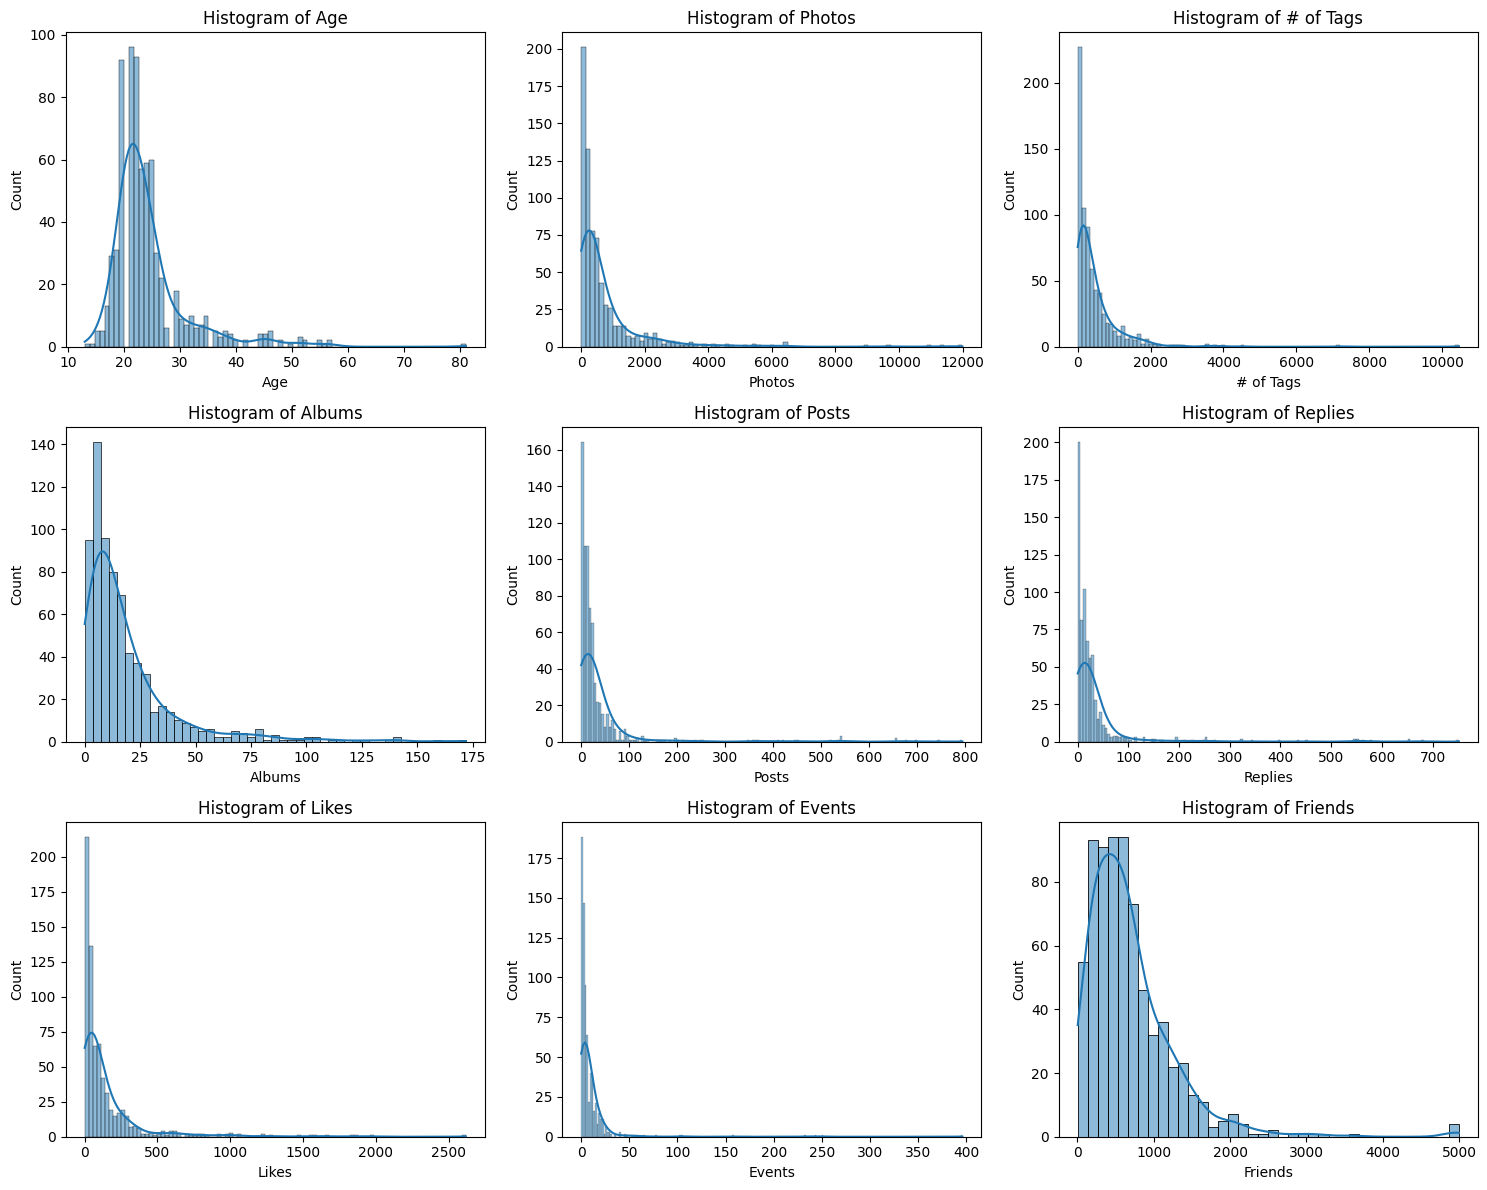

In [ ]:
import io

# 1. Data Access
# Load Facebook Friends.csv
# It has "tab separated data inside a quoted field", followed by commas.
# We can read the first column and then split it.
temp_csv = pd.read_csv('Facebook Friends.csv', header=None, quotechar='"')
# Column 0 contains the tab separated data.
df_csv = temp_csv[0].str.split('\t', expand=True)
df_csv.columns = df_csv.iloc[0].str.strip()
df_csv = df_csv[1:].reset_index(drop=True)

# Load Facebook Friends.txt
df_txt = pd.read_csv('/content/Facebook Friends.txt', encoding='utf-16', sep='\t')
df_txt = df_txt.loc[:, ~df_txt.columns.str.startswith('Unnamed:')]
df_txt.columns = df_txt.columns.str.strip()

# Load Facebook Friends.xlsx using read_excel (corrected file name and method)
df_xlsx = pd.read_excel('/content/Facebook Friends.xlsx')

# Compare
print("CSV Dataframe shape:", df_csv.shape)
print("TXT Dataframe shape:", df_txt.shape)
print("XLSX Dataframe shape:", df_xlsx.shape)

print("\nCSV Columns:", df_csv.columns.tolist())
print("XLSX Columns:", df_xlsx.columns.tolist())

# Check for differences in content (just the first few rows of common columns)
common_cols = ['Age', 'Photos', 'Friends']
print("\nFirst 3 rows comparison (Age, Photos, Friends):")
print("CSV:\n", df_csv[common_cols].head(3))
print("XLSX:\n", df_xlsx[['Age', 'Photos', 'Friends']].head(3))

# 2. Data Examination
print("\n--- Data Examination (Excel Dataframe) ---")
print("Top 5 rows:")
print(df_xlsx.head())
print("\nBottom 5 rows:")
print(df_xlsx.tail())
print("\nColumn Headings:")
print(df_xlsx.columns)
print("\nData Types and Missing Values:")
print(df_xlsx.info())
print("\nMissing Data Count:")
print(df_xlsx.isnull().sum())

# 3. Data Stats
print("\n--- Data Stats ---")
desc = df_xlsx.describe()
print(desc)

# 4. Data Viz
numerical_cols = ['Age', 'Photos', '# of Tags', 'Albums', 'Posts', 'Replies', 'Likes', 'Events', 'Friends']

# Plotting histograms
plt.figure(figsize=(15, 12))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df_xlsx[col], kde=True)
    plt.title(f'Histogram of {col}')
plt.tight_layout()
plt.savefig('histograms.png')